# Inferential Statistics — CS Students Dataset

---


## Dataset Overview


In [2]:
# for basic operations
import numpy as np
import pandas as pd

# for data visualizations
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
df = pd.read_csv('cs_students.csv')
df.shape

(180, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


## Basic Probability


In [5]:
df.columns

Index(['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major',
       'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL',
       'Java'],
      dtype='object')

In [6]:
print("Checking the different interested domains in the dataset:")
df["Interested Domain"].value_counts()

Checking the different interested domains in the dataset:


Interested Domain
Artificial Intelligence           19
Web Development                   19
Cybersecurity                     18
Mobile App Development            17
Database Management               16
Cloud Computing                   16
Data Science                      13
Machine Learning                  13
Computer Graphics                 13
Software Development              11
Software Engineering               5
Quantum Computing                  2
Bioinformatics                     2
Human-Computer Interaction         2
Biomedical Computing               2
Distributed Systems                1
Geographic Information Systems     1
Data Privacy                       1
Information Retrieval              1
Blockchain Technology              1
Computer Vision                    1
Data Mining                        1
Natural Language Processing        1
IoT (Internet of Things)           1
Game Development                   1
Network Security                   1
Digital Forensics   

In [7]:
all_students = df.shape[0]
print("Total number of students:", all_students)

# students interested in Artificial Intelligence
ai_students = df[df["Interested Domain"] == "Artificial Intelligence"].shape[0]
print("Number of students interested in AI:", ai_students)

# probability of a student being interested in AI
probability = (ai_students / all_students) * 100
print("Probability of a student being interested in AI:", probability, '%')

Total number of students: 180
Number of students interested in AI: 19
Probability of a student being interested in AI: 10.555555555555555 %


## Conditional Probability


In [8]:
# the probability of being interested in AI given the student is Male vs Female

male_students   = df[df["Gender"] == "Male"]
female_students = df[df["Gender"] == "Female"]

ai_given_male   = (male_students["Interested Domain"] == "Artificial Intelligence").mean()
ai_given_female = (female_students["Interested Domain"] == "Artificial Intelligence").mean()

print(f"Probability of AI interest given Male:   {ai_given_male:.4f}")
print(f"Probability of AI interest given Female: {ai_given_female:.4f}")

Probability of AI interest given Male:   0.1373
Probability of AI interest given Female: 0.0641


## Normal Distribution


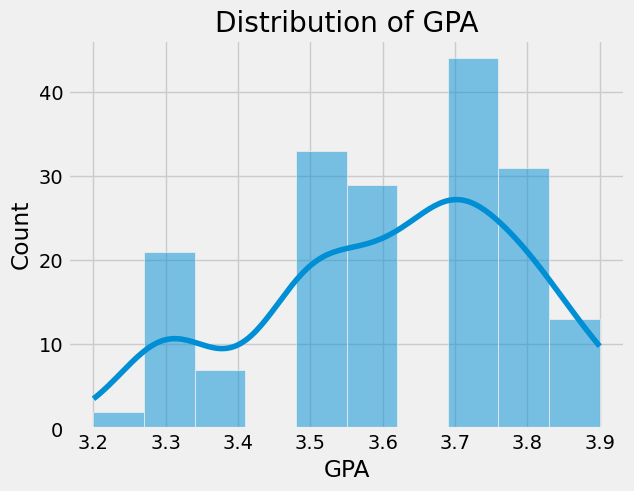

In [9]:
plt.style.use("fivethirtyeight")

sns.histplot(df['GPA'], kde=True)
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.show()

- The distribution of GPA shows whether student performance follows a normal bell curve or is skewed toward higher/lower grades.

In [10]:
print("Mean GPA:",    df["GPA"].mean())
print("Median GPA:",  df["GPA"].median())
print("Skewness:",    df["GPA"].skew())

Mean GPA: 3.615
Median GPA: 3.6
Skewness: -0.4000367650563136


## Z-Score
Z-score is used to measure how far each student's GPA is from the average.

In [11]:
# calculating the mean and standard deviation of the GPA column
gpa_mean = df["GPA"].mean()
gpa_std  = df["GPA"].std()
print("Standard Deviation of GPA:", gpa_std)
print("Mean GPA:", gpa_mean)

# calculating the z-score for each student's GPA
df["z_score"] = (df["GPA"] - gpa_mean) / gpa_std

# identifying outliers based on a z-score threshold (|Z| > 2)
outliers = df[abs(df["z_score"]) > 2]
print(outliers[["Name", "GPA", "z_score", "Interested Domain"]].sort_values(by="z_score", ascending=False))

Standard Deviation of GPA: 0.17734069096062274
Mean GPA: 3.615
             Name  GPA   z_score Interested Domain
1   Alice Johnson  3.2 -2.340128      Data Science
94  Alice Johnson  3.2 -2.340128   Computer Vision


## Inference

### Sample Mean and Population Mean


In [12]:
# lets take seed so that every time the random values come out to be constant
np.random.seed(47)

# lets take 50 sample values from the dataset
sample = np.random.choice(a=df["GPA"], size=50)

# getting the sample mean
print("Sample mean:", sample.mean())

# getting the population mean
print("Population mean:", df["GPA"].mean())

Sample mean: 3.5980000000000008
Population mean: 3.615


## Central Limit Theorem


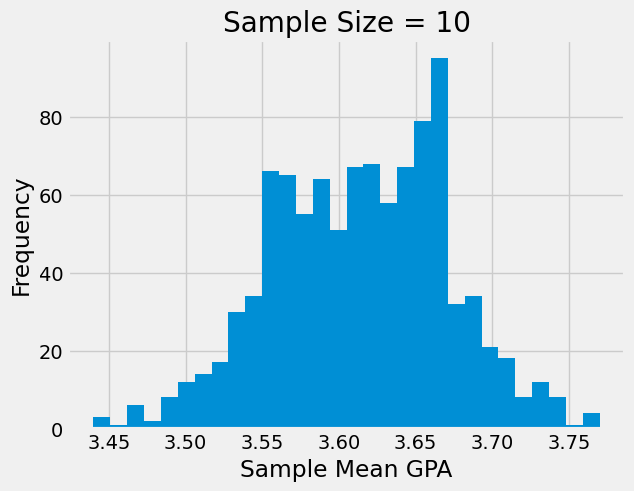

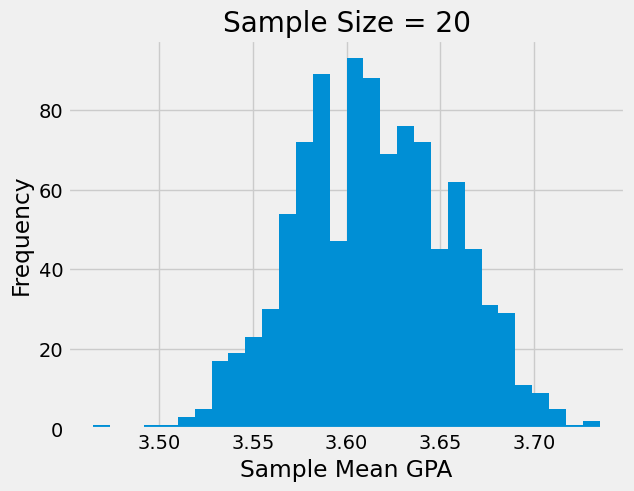

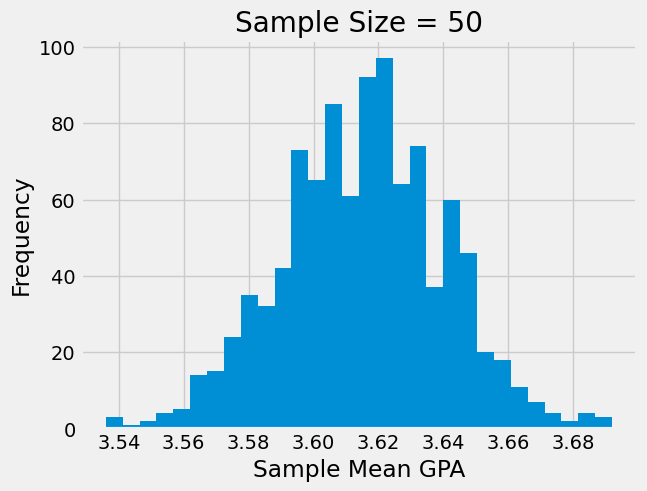

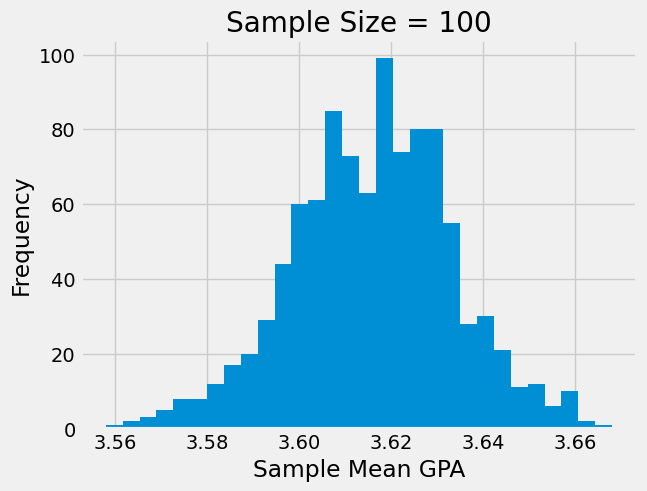

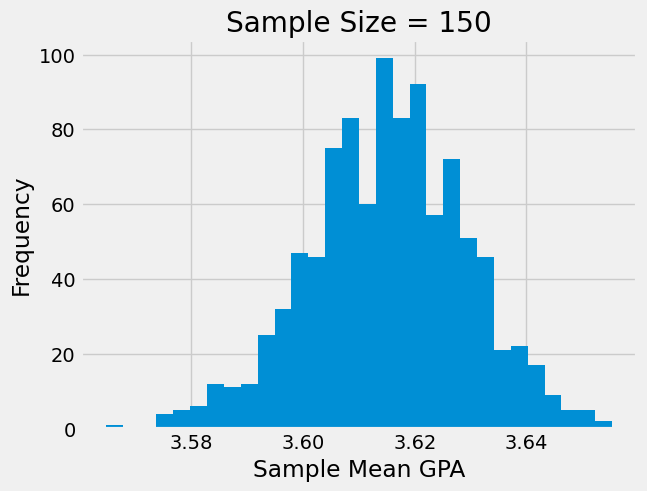

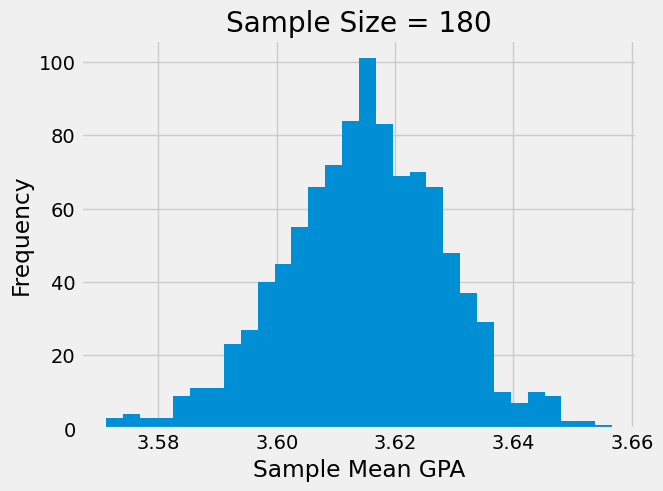

In [13]:
# number of samples to average over
n = np.array([10, 20, 50, 100, 150, 180])

# number of times samples of size n are taken
N = 1000

for size in n:
    sample_means = []

    for _ in range(N):
        sample = np.random.choice(df['GPA'], size=size)
        sample_means.append(np.mean(sample))

    plt.figure()
    plt.hist(sample_means, bins=30)
    plt.title(f"Sample Size = {size}")
    plt.xlabel("Sample Mean GPA")
    plt.ylabel("Frequency")
    plt.show()

- As sample size increases, the distribution of sample means approaches a normal distribution, confirming the Central Limit Theorem.

## Confidence Interval


In [14]:
import scipy.stats as stats
import math

# lets seed the random values
np.random.seed(10)

# lets take a sample size
sample_size = 50
sample = np.random.choice(a=df["GPA"], size=sample_size)
sample_mean = sample.mean()

# Get the z-critical value
z_critical = stats.norm.ppf(q=0.95)
print("z-critical value:", z_critical)

# Get the population standard deviation
pop_stdev = df["GPA"].std()

# checking the margin of error
margin_of_error = z_critical * (pop_stdev / math.sqrt(sample_size))

# defining our confidence interval
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

# lets print the results
print("Confidence interval:", end=" ")
print(f"[{confidence_interval[0]:.4f} , {confidence_interval[1]:.4f}]")
print("True mean: {}".format(df["GPA"].mean()))

z-critical value: 1.6448536269514722
Confidence interval: [3.5447 , 3.6273]
True mean: 3.615


- The confidence interval contains the true mean, which shows that the estimation is reliable.

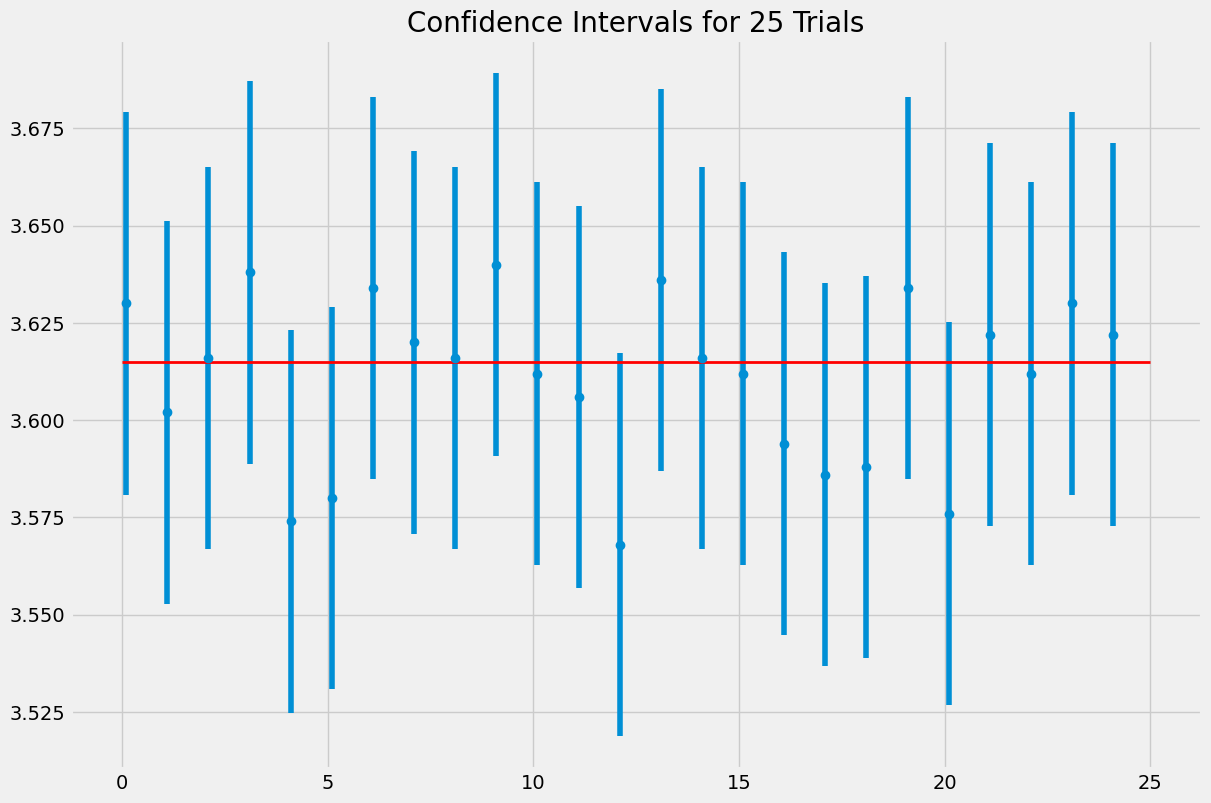

In [15]:
np.random.seed(12)

sample_size = 50

intervals = []
sample_means = []

for sample in range(25):
    sample = np.random.choice(a=df["GPA"], size=sample_size)
    sample_mean = sample.mean()
    sample_means.append(sample_mean)

    z_critical    = stats.norm.ppf(q=0.975)
    pop_stdev     = df["GPA"].std()
    margin_of_error = z_critical * (pop_stdev / math.sqrt(sample_size))
    confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
    intervals.append(confidence_interval)


plt.figure(figsize=(13, 9))

plt.errorbar(
    x=np.arange(0.1, 25, 1),
    y=sample_means,
    yerr=[(bot - top) / 2 for top, bot in intervals],
    fmt="o",
)

plt.hlines(xmin=0, xmax=25, y=df["GPA"].mean(), linewidth=2.0, color="red")
plt.title("Confidence Intervals for 25 Trials", fontsize=20)
plt.show()

- Most sample intervals contain the true mean. A few may miss due to sampling variation.

## Hypothesis Testing

**Question:**  
Do students with strong Python skills have a higher GPA than the overall average, or is it just random variation?

**Hypothesis setting:**
- H₀ (Null Hypothesis): Students with strong Python skills have the same average GPA as overall students  
- H₁ (Alternative Hypothesis): Students with strong Python skills have a different average GPA  

α = 0.05 (We accept a 5% risk of making a wrong decision)

We will use statistical tests (Z-test and T-test) to determine whether to reject the null hypothesis.


### Z-Test

The Z-test is used to determine whether the mean GPA of students with strong Python skills differs from the overall population mean.


In [16]:
from statsmodels.stats.weightstats import ztest

strong_python = df[df["Python"] == "Strong"]["GPA"]
z_statistic, p_value = ztest(
    x1=strong_python,
    value=df["GPA"].mean(),
)

print("Z-statistic is: {}".format(z_statistic))
print("P-value is: {:.10f}".format(p_value))

print("Number of strong Python students:", strong_python.shape[0])
print("Mean GPA (strong Python):", round(strong_python.mean(), 4))
print("Mean GPA (overall):",       round(df["GPA"].mean(), 4))

Z-statistic is: 4.563737370489423
P-value is: 0.0000050251
Number of strong Python students: 70
Mean GPA (strong Python): 3.7043
Mean GPA (overall): 3.615


### T-Test

The T-test compares the mean GPA of students with strong Python skills vs. those without.


In [17]:
from scipy.stats import ttest_ind

strong_python = df[df["Python"] == "Strong"]["GPA"]
other_python  = df[df["Python"] != "Strong"]["GPA"]

t_stat, p_value = ttest_ind(strong_python, other_python)

print("T-statistic:", t_stat)
print("P-value: {:.10f}".format(p_value))
print("Number of strong Python students:", strong_python.shape[0])
print("Number of other students:",         other_python.shape[0])
print("Mean GPA (strong Python):", round(strong_python.mean(), 4))
print("Mean GPA (other):",         round(other_python.mean(), 4))

T-statistic: 5.8705374821527245
P-value: 0.0000000208
Number of strong Python students: 70
Number of other students: 110
Mean GPA (strong Python): 3.7043
Mean GPA (other): 3.5582


**Conclusion:**  
- If p < 0.05, we reject H₀ and conclude that Python skill level is significantly associated with GPA.

### Type 1 and Type 2 Error
- **Type 1:** Rejecting the null hypothesis when it is actually true.  
  > Concluding Python skill affects GPA when it actually doesn't.
- **Type 2:** Failing to reject the null hypothesis when it is false.  
  > Missing a real relationship between Python skill and GPA.


### Chi-Squared Test of Independence

Is there a relationship between **Gender** and **Interested Domain**?


In [18]:
from scipy.stats import chi2_contingency

# keep top 5 domains to keep the table readable
top_domains = df["Interested Domain"].value_counts().head(5).index
df_top = df[df["Interested Domain"].isin(top_domains)]

freq_table = pd.crosstab(df_top["Interested Domain"], df_top["Gender"])

print("Frequency Table: Interested Domain vs Gender")
print("============================")
print(freq_table)
print("============================")

chi2, p, dof, expected = chi2_contingency(freq_table)
print("\nChi-square statistic:", chi2)
print("P-value:", p)

Frequency Table: Interested Domain vs Gender
Gender                   Female  Male
Interested Domain                    
Artificial Intelligence       5    14
Cybersecurity                 9     9
Database Management           8     8
Mobile App Development        9     8
Web Development               5    14

Chi-square statistic: 5.540079735965886
P-value: 0.23622883793063212


### Chi-Squared Goodness of Fit Test

Are the different skill levels (Strong / Average / Weak) equally distributed among students?


In [19]:
from scipy.stats import chisquare

observed = df['Python'].value_counts()

expected = [len(df) / len(observed)] * len(observed)

print('Expected value per category:', expected[0])

chi2, p = chisquare(observed, f_exp=expected)

print("\nObserved counts:")
print("============================")
print(observed)
print("============================")

print("\nChi-square statistic:", chi2)
print("P-value:", p)

Expected value per category: 60.0

Observed counts:
Python
Strong     70
Weak       64
Average    46
Name: count, dtype: int64

Chi-square statistic: 5.2
P-value: 0.07427357821433386
